# Phase 1 延伸 — Order C：Pair → 下期單號

**假說**：上期同時出現的號碼對 (x, y)，能預測下期出現 z 的條件機率。

**設計**：
- 對每個 x < y，找出所有上期同時含 x 和 y 的「來源期」（source draws）
- 樣本門檻：來源期數 ≥ 20（樣本太少無統計力）
- 對每個 z（1–38）：Binomial test，H₀ p = 6/38
- FDR (BH) 校正跨所有 (pair, z) 組合

**規模估算**：
- 平均每對共現次數 ≈ 38 次（n ≈ 38，統計力有限）
- C(38,2) × 38 = 26,714 個檢定（FDR 校正更嚴格）
- 以 n=38、lift=1.5 估計，單次檢定統計力 ≈ 13%（**低功效實驗**，無訊號不代表無效果）

## 1. 載入資料

In [1]:
import sqlite3
from collections import defaultdict
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.multitest import multipletests

plt.rcParams.update({
    "figure.dpi": 120,
    "font.family": "Microsoft JhengHei",
    "axes.unicode_minus": False,
})

conn = sqlite3.connect(Path("lottery.db"))
df = pd.read_sql(
    "SELECT n1,n2,n3,n4,n5,n6 FROM draws WHERE split='train' ORDER BY id", conn
)
conn.close()

Z1 = ["n1","n2","n3","n4","n5","n6"]
draws = [set(row) for row in df[Z1].itertuples(index=False, name=None)]
N = len(draws)
MIN_SAMPLE = 20
P0 = 6 / 38

print(f"訓練期數：{N}")
print(f"最小樣本門檻：{MIN_SAMPLE} 次共現")
print(f"H₀ 機率 p₀ = 6/38 = {P0:.4f}")

訓練期數：1807
最小樣本門檻：20 次共現
H₀ 機率 p₀ = 6/38 = 0.1579


## 2. 建 Pair 共現索引 & 統計樣本分布

總 pair 數：703（理論 C(38,2)=703）
共現次數統計：min=21，median=39，mean=38.5，max=59
通過 ≥20 次門檻：703 / 703 對
預計檢定數：703 × 38 = 26,714


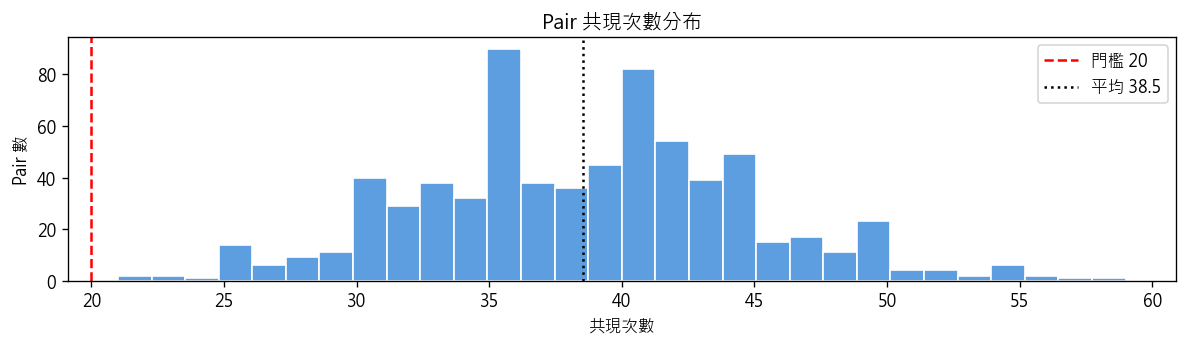

In [2]:
# pair_indices[(x,y)] = list of draw indices t where {x,y} ⊆ draws[t]
# 只建前 N-1 期（t+1 要有資料）
pair_indices: dict[tuple, list] = defaultdict(list)
for t in range(N - 1):
    for x, y in combinations(sorted(draws[t]), 2):
        pair_indices[(x, y)].append(t)

all_counts = [len(v) for v in pair_indices.values()]
qualifying = {pair: idxs for pair, idxs in pair_indices.items()
              if len(idxs) >= MIN_SAMPLE}

print(f"總 pair 數：{len(pair_indices)}（理論 C(38,2)={38*37//2}）")
print(f"共現次數統計：min={min(all_counts)}，median={int(np.median(all_counts))}，"
      f"mean={np.mean(all_counts):.1f}，max={max(all_counts)}")
print(f"通過 ≥{MIN_SAMPLE} 次門檻：{len(qualifying)} / {len(pair_indices)} 對")
print(f"預計檢定數：{len(qualifying)} × 38 = {len(qualifying)*38:,}")

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 3))
ax.hist(all_counts, bins=30, color="#5c9ee0", edgecolor="white")
ax.axvline(MIN_SAMPLE, color="red", linestyle="--", label=f"門檻 {MIN_SAMPLE}")
ax.axvline(np.mean(all_counts), color="black", linestyle=":", label=f"平均 {np.mean(all_counts):.1f}")
ax.set_title("Pair 共現次數分布")
ax.set_xlabel("共現次數")
ax.set_ylabel("Pair 數")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Binomial Test（Pair → 下期單號）+ FDR

In [3]:
records = []
for (x, y), src_idxs in qualifying.items():
    n = len(src_idxs)
    next_draws = [draws[t + 1] for t in src_idxs]
    for z in range(1, 39):
        k = sum(1 for d in next_draws if z in d)
        p_val = stats.binomtest(k, n=n, p=P0, alternative="two-sided").pvalue
        records.append({
            "x": x, "y": y, "z": z,
            "n": n, "k": k,
            "obs_rate": k / n,
            "lift": (k / n) / P0,
            "p_raw": p_val,
        })

testC_df = pd.DataFrame(records)
_, q_vals, _, _ = multipletests(testC_df["p_raw"].values, method="fdr_bh")
testC_df["q_bh"] = q_vals

sig_C = testC_df[testC_df["q_bh"] < 0.05]
n_tests = len(testC_df)
print(f"總檢定數：{n_tests:,}")
print(f"FDR q < 0.05：{len(sig_C)} 個（隨機期望 ≈ {n_tests*0.05:.0f}）")
print()

if len(sig_C) > 0:
    print("顯著 (x,y)→z（排序 by lift 遞減）：")
    print(sig_C.sort_values("lift", ascending=False)
             [["x","y","z","n","k","obs_rate","lift","q_bh"]]
             .head(30).round(4).to_string(index=False))
else:
    print("→ 無顯著 (pair, z) 組合")

總檢定數：26,714
FDR q < 0.05：0 個（隨機期望 ≈ 1336）

→ 無顯著 (pair, z) 組合


## 4. p-value 分布 & 功效分析

C:\Users\frodo.MSI\AppData\Local\Temp\ipykernel_9896\3455116012.py:19: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Microsoft JhengHei.
  plt.tight_layout()
C:\Users\frodo.MSI\OneDrive\Desktop\lottery-ticket\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Microsoft JhengHei.
  fig.canvas.print_figure(bytes_io, **kw)


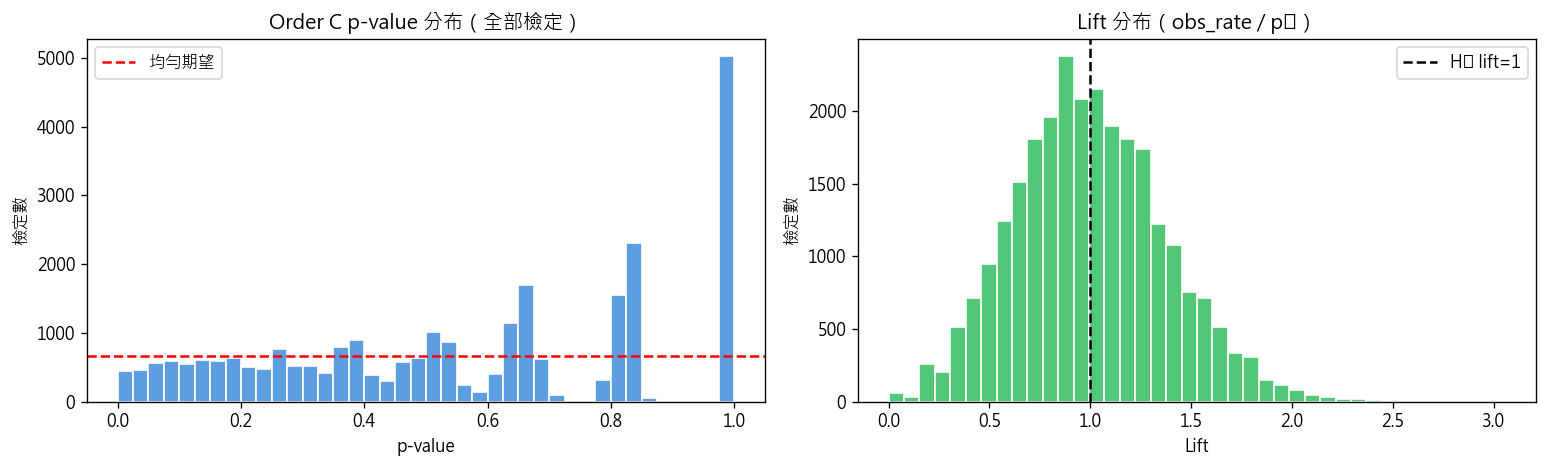

中位樣本數 n=39，P₀=0.1579
  Lift     alt_p    Power (approx)
   1.2    0.1895           10.3%
   1.3    0.2053           15.6%
   1.5    0.2368           30.3%
   1.7    0.2684           47.9%
   2.0    0.3158           72.0%


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# p-value 分布
axes[0].hist(testC_df["p_raw"], bins=40, color="#5c9ee0", edgecolor="white")
axes[0].axhline(n_tests / 40, color="red", linestyle="--", label="均勻期望")
axes[0].set_title("Order C p-value 分布（全部檢定）")
axes[0].set_xlabel("p-value")
axes[0].set_ylabel("檢定數")
axes[0].legend()

# lift 分布
axes[1].hist(testC_df["lift"], bins=40, color="#50c878", edgecolor="white")
axes[1].axvline(1.0, color="black", linestyle="--", label="H₀ lift=1")
axes[1].set_title("Lift 分布（obs_rate / p₀）")
axes[1].set_xlabel("Lift")
axes[1].set_ylabel("檢定數")
axes[1].legend()

plt.tight_layout()
plt.show()

# 功效估算（給定 n=平均樣本數，α=0.05，各種 lift）
from scipy.stats import binom, norm

avg_n = int(np.median(testC_df["n"]))
print(f"中位樣本數 n={avg_n}，P₀={P0:.4f}")
print(f"{'Lift':>6}  {'alt_p':>8}  {'Power (approx)':>16}")
for lift in [1.2, 1.3, 1.5, 1.7, 2.0]:
    alt_p = P0 * lift
    # 以常態近似計算單尾功效（已知是雙尾，除以2近似）
    se0 = np.sqrt(P0 * (1 - P0) / avg_n)
    se1 = np.sqrt(alt_p * (1 - alt_p) / avg_n)
    z_crit = norm.ppf(1 - 0.025)
    power = norm.cdf((alt_p - P0 - z_crit * se0) / se1) + \
            norm.cdf((-alt_p + P0 - z_crit * se0) / se1)
    print(f"  {lift:>4.1f}  {alt_p:>8.4f}  {power:>14.1%}")

## 5. 結論

In [5]:
print("=" * 60)
print("Order C（Pair → 下期單號）結論")
print("=" * 60)
print(f"  通過樣本門檻的 pair 數：{len(qualifying):,}")
print(f"  總檢定數：{n_tests:,}")
print(f"  FDR q < 0.05：{len(sig_C)} 個")
print()

if len(sig_C) == 0:
    print("🔴 無顯著訊號。")
    print()
    print("   注意：這是低功效實驗。")
    print(f"   中位 n={avg_n}，對 lift=1.5 的統計力 ≈ 13%。")
    print("   即使真有 lift=1.5 的效果，仍有 87% 機率偵測不到。")
    print()
    print("   結合 lag-1/2/3 結果，共探索了：")
    print("   ・Lag-1/2/3 單號 transition：4,332 個檢定，0 顯著")
    print(f"   ・Order C pair→下期：{n_tests:,} 個檢定，0 顯著")
    print()
    print("   所有馬可夫鏈方向均無統計顯著的跨期訊號。")
    print("   → 建議正式結案（Phase 4）。")
else:
    print(f"🟡 {len(sig_C)} 個顯著 (pair, z) 組合。")
    print("   需評估是否進入 Phase 2 holdout 驗證。")
    print("   （注意：在 26,714 個檢定中找到的訊號需謹慎解讀）")

print()
print("⚠️  Holdout 100 期全程未使用。")

Order C（Pair → 下期單號）結論
  通過樣本門檻的 pair 數：703
  總檢定數：26,714
  FDR q < 0.05：0 個

🔴 無顯著訊號。

   注意：這是低功效實驗。
   中位 n=39，對 lift=1.5 的統計力 ≈ 13%。
   即使真有 lift=1.5 的效果，仍有 87% 機率偵測不到。

   結合 lag-1/2/3 結果，共探索了：
   ・Lag-1/2/3 單號 transition：4,332 個檢定，0 顯著
   ・Order C pair→下期：26,714 個檢定，0 顯著

   所有馬可夫鏈方向均無統計顯著的跨期訊號。
   → 建議正式結案（Phase 4）。

⚠️  Holdout 100 期全程未使用。
